# AIF 2026 | Week 7 | Phase 2: Foundational Statistical Learning
## Clustering Assignment: Market Segmentation

**Dataset:** UCI Online Retail II, sheet `Year 2010-2011`  
**Goal:** transform raw transaction rows into one customer-level feature matrix, discover natural customer groups, validate the clusters, and translate the final segmentation into marketing actions.

This notebook is written as a reproducible analysis: every preprocessing and modeling choice is documented where it is made.

## 0. Environment Setup

The notebook uses common scientific Python libraries only. `openpyxl` is needed because the UCI file is distributed as an Excel workbook, and the remaining libraries support clustering, validation, and plots.

In [1]:
# Core data work
import os
import zipfile
import urllib.request
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and models
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

# Hierarchical dendrograms
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

RANDOM_STATE = 42
DATA_URL = 'https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip'
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

## 1. Data Loading and First Look

I load the raw transactions before making any cleaning decisions. The workbook uses legacy column names (`Invoice`, `Price`, `Customer ID`), so I standardize names immediately after loading to keep the rest of the notebook readable.

In [2]:
zip_path = DATA_DIR / 'online_retail_II.zip'
xlsx_path = DATA_DIR / 'online_retail_II.xlsx'

if not xlsx_path.exists():
    print('Downloading UCI Online Retail II archive...')
    urllib.request.urlretrieve(DATA_URL, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as zf:
        xlsx_members = [m for m in zf.namelist() if m.lower().endswith('.xlsx')]
        if not xlsx_members:
            raise FileNotFoundError('No .xlsx file found inside the UCI archive.')
        zf.extract(xlsx_members[0], DATA_DIR)
        extracted = DATA_DIR / xlsx_members[0]
        if extracted != xlsx_path:
            extracted.rename(xlsx_path)
else:
    print('Using cached dataset:', xlsx_path)

raw_df = pd.read_excel(xlsx_path, sheet_name='Year 2010-2011')
raw_df = raw_df.rename(columns={
    'Invoice': 'InvoiceNo',
    'Customer ID': 'CustomerID',
    'Price': 'UnitPrice',
})

print('Raw shape:', raw_df.shape)
display(raw_df.head())
print('\nColumn types:')
display(raw_df.dtypes)
print('\nMissing values:')
display(raw_df.isna().sum().sort_values(ascending=False))
print('\nInvoice date range:', raw_df['InvoiceDate'].min(), 'to', raw_df['InvoiceDate'].max())

Using cached dataset: data\online_retail_II.xlsx


Raw shape: (541910, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom



Column types:


InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


Missing values:


CustomerID     135080
Description      1454
StockCode           0
InvoiceNo           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64


Invoice date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


**Initial observations.** The data is transactional, not customer-level, so a customer can appear in many rows within the same invoice. `CustomerID` has missing values; these rows cannot be assigned to a customer segment, so they are not useful for customer clustering. Cancellations appear as invoice numbers beginning with `C` and often negative quantities, so they should not be mixed with successful purchases when calculating RFM. Spend is not directly provided but can be engineered as `Quantity * UnitPrice`.

## 2. Data Cleaning

I keep two versions of the data:

- `raw_customer_df`: transactions with a known customer, including cancellations. This is used only to compute return/cancellation behavior.
- `clean_df`: successful purchase rows only. This is used for RFM, basket size, category spend, and purchase gaps.

In [3]:
df = raw_df.copy()
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

initial_rows = len(df)
raw_customer_df = df.dropna(subset=['CustomerID']).copy()
raw_customer_df['CustomerID'] = raw_customer_df['CustomerID'].astype(int)
raw_customer_df['IsCancellation'] = raw_customer_df['InvoiceNo'].str.startswith('C')

# Return rate is computed before removing cancellations because cancellations are behavioral signal.
return_features = raw_customer_df.assign(
    PositiveQuantity=lambda x: np.where((~x['IsCancellation']) & (x['Quantity'] > 0), x['Quantity'], 0),
    CancelledQuantity=lambda x: np.where(x['IsCancellation'] | (x['Quantity'] < 0), np.abs(x['Quantity']), 0),
).groupby('CustomerID').agg(
    PositiveQuantity=('PositiveQuantity', 'sum'),
    CancelledQuantity=('CancelledQuantity', 'sum'),
)
return_features['ReturnRate'] = return_features['CancelledQuantity'] / (
    return_features['PositiveQuantity'] + return_features['CancelledQuantity']
).replace(0, np.nan)
return_features['ReturnRate'] = return_features['ReturnRate'].fillna(0)

clean_df = raw_customer_df.copy()
clean_df = clean_df[~clean_df['IsCancellation']]
clean_df = clean_df[(clean_df['Quantity'] > 0) & (clean_df['UnitPrice'] > 0)]
clean_df['Revenue'] = clean_df['Quantity'] * clean_df['UnitPrice']

cleaning_summary = pd.DataFrame({
    'Step': ['Raw rows', 'Known customer rows', 'Successful positive purchase rows'],
    'Rows': [initial_rows, len(raw_customer_df), len(clean_df)],
})
cleaning_summary['Rows Removed vs Raw'] = initial_rows - cleaning_summary['Rows']
display(cleaning_summary)
print('Unique customers retained for purchase features:', clean_df['CustomerID'].nunique())

,Step,Rows,Rows Removed vs Raw
0,Raw rows,541910,0
1,Known customer rows,406830,135080
2,Successful positive purchase rows,397885,144025


Unique customers retained for purchase features: 4338


## 3. Feature Engineering: Customer Matrix

The required RFM features capture the core customer relationship: how recently the customer purchased, how often they purchased, and how much they spent. I also add behavioral features that can separate customers with similar RFM values but different shopping patterns.

- **ReturnRate:** customers who frequently cancel/return may need service recovery or better expectation-setting.
- **AvgBasketSize:** separates frequent small-order buyers from fewer but larger-basket buyers.
- **AvgGapDays:** distinguishes regular cadence from sporadic buying.
- **Category spend ratios:** customers with the same total spend can have different product interests; ratios encode preference without simply duplicating monetary value.

In [4]:
def assign_category(description):
    """Map noisy product descriptions into broad retail categories for spend-ratio features."""
    text = str(description).lower()
    if any(word in text for word in ['christmas', 'easter', 'valentine', 'halloween', 'party', 'birthday']):
        return 'Seasonal_Party'
    if any(word in text for word in ['bag', 'box', 'basket', 'holder', 'storage', 'tin']):
        return 'Storage_Bags'
    if any(word in text for word in ['cup', 'mug', 'plate', 'bowl', 'tea', 'coffee', 'cake', 'kitchen']):
        return 'Kitchen_Table'
    if any(word in text for word in ['heart', 'sign', 'frame', 'candle', 'light', 'clock', 'decoration']):
        return 'Home_Decor'
    if any(word in text for word in ['child', 'toy', 'game', 'doll', 'school']):
        return 'Kids_Toys'
    if any(word in text for word in ['necklace', 'bracelet', 'ring', 'earring', 'jewellery', 'hair']):
        return 'Accessories'
    return 'Other'

reference_date = clean_df['InvoiceDate'].max() + pd.Timedelta(days=1)
# I use one day after the latest purchase so a customer who bought on the final day has Recency = 1,
# which avoids zero-day edge cases during log transformation.

invoice_level = clean_df.groupby(['CustomerID', 'InvoiceNo'], as_index=False).agg(
    InvoiceDate=('InvoiceDate', 'min'),
    InvoiceRevenue=('Revenue', 'sum'),
    Items=('Quantity', 'sum'),
)

rfm = clean_df.groupby('CustomerID').agg(
    LastPurchase=('InvoiceDate', 'max'),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum'),
    TotalItems=('Quantity', 'sum'),
    Country=('Country', lambda s: s.mode().iat[0] if not s.mode().empty else 'Unknown'),
)
rfm['Recency'] = (reference_date - rfm['LastPurchase']).dt.days
rfm['AvgBasketSize'] = rfm['Monetary'] / rfm['Frequency']

purchase_gaps = invoice_level.sort_values(['CustomerID', 'InvoiceDate']).groupby('CustomerID')['InvoiceDate'].apply(
    lambda dates: dates.diff().dt.days.mean()
)
rfm['AvgGapDays'] = purchase_gaps
rfm['OneTimeBuyer'] = (rfm['Frequency'] == 1).astype(int)

category_df = clean_df.copy()
category_df['Category'] = category_df['Description'].apply(assign_category)
category_spend = category_df.pivot_table(
    index='CustomerID', columns='Category', values='Revenue', aggfunc='sum', fill_value=0
)
category_ratios = category_spend.div(category_spend.sum(axis=1), axis=0).add_prefix('SpendRatio_')

customer_df = rfm.join(return_features[['ReturnRate']], how='left').join(category_ratios, how='left')
customer_df['ReturnRate'] = customer_df['ReturnRate'].fillna(0)
ratio_cols = [c for c in customer_df.columns if c.startswith('SpendRatio_')]
customer_df[ratio_cols] = customer_df[ratio_cols].fillna(0)

# A one-invoice customer has no observed gap between purchases. I impute 0 and keep the OneTimeBuyer flag
# so the model can distinguish "no repeat interval yet" from a short repeated-purchase interval.
customer_df['AvgGapDays'] = customer_df['AvgGapDays'].fillna(0)

model_features = [
    'Recency', 'Frequency', 'Monetary', 'AvgBasketSize', 'AvgGapDays',
    'ReturnRate', 'OneTimeBuyer',
] + ratio_cols

print('Customer feature matrix shape:', customer_df[model_features].shape)
display(customer_df[model_features].head())
display(customer_df[model_features].describe().T)

Customer feature matrix shape: (4338, 14)


,Recency,Frequency,Monetary,AvgBasketSize,AvgGapDays,ReturnRate,OneTimeBuyer,SpendRatio_Accessories,SpendRatio_Home_Decor,SpendRatio_Kids_Toys,SpendRatio_Kitchen_Table,SpendRatio_Other,SpendRatio_Seasonal_Party,SpendRatio_Storage_Bags
CustomerID,,,,,,,,,,,,,,
12346,326,1,"77,183.60","77,183.60",0.00,0.50,1,0.00,0.00,0.00,0.00,0.00,0.00,1.00
12347,2,7,"4,310.00",615.71,60.33,0.00,0,0.00,0.25,0.02,0.19,0.34,0.01,0.19
12348,75,4,"1,797.24",449.31,94.00,0.00,0,0.00,0.07,0.00,0.15,0.74,0.04,0.00
12349,19,1,"1,757.55","1,757.55",0.00,0.00,1,0.01,0.13,0.01,0.09,0.48,0.01,0.26
12350,310,1,334.40,334.40,0.00,0.00,1,0.00,0.20,0.00,0.00,0.57,0.00,0.22


,count,mean,std,min,25%,50%,75%,max
Recency,"4,338.00",92.54,100.01,1.00,18.00,51.00,142.00,374.00
Frequency,"4,338.00",4.27,7.70,1.00,1.00,2.00,5.00,209.00
Monetary,"4,338.00","2,054.27","8,989.23",3.75,307.41,674.49,"1,661.74","280,206.02"
AvgBasketSize,"4,338.00",419.17,"1,796.54",3.45,178.62,293.90,430.11,"84,236.25"
AvgGapDays,"4,338.00",47.34,63.18,0.00,0.00,28.00,68.00,365.00
ReturnRate,"4,338.00",0.01,0.06,0.00,0.00,0.00,0.01,1.00
OneTimeBuyer,"4,338.00",0.34,0.48,0.00,0.00,0.00,1.00,1.00
SpendRatio_Accessories,"4,338.00",0.02,0.05,0.00,0.00,0.00,0.01,0.91
SpendRatio_Home_Decor,"4,338.00",0.19,0.16,0.00,0.07,0.16,0.26,1.00
SpendRatio_Kids_Toys,"4,338.00",0.03,0.06,0.00,0.00,0.00,0.03,1.00


## 4. Preprocessing

Distance-based clustering is sensitive to feature scale. Without scaling, monetary variables measured in currency would dominate ratios measured from 0 to 1 and recency measured in days. The behavioral variables are also strongly right-skewed, so I use `log1p` on count, spend, and day-gap variables, cap extreme transformed values with the IQR rule, and then apply `RobustScaler`. I choose `RobustScaler` over `StandardScaler` because retail data naturally contains very large legitimate spenders; robust scaling uses medians and IQRs, so those customers do not distort the whole feature space.

,Missing values


Any missing values after engineered imputations? False


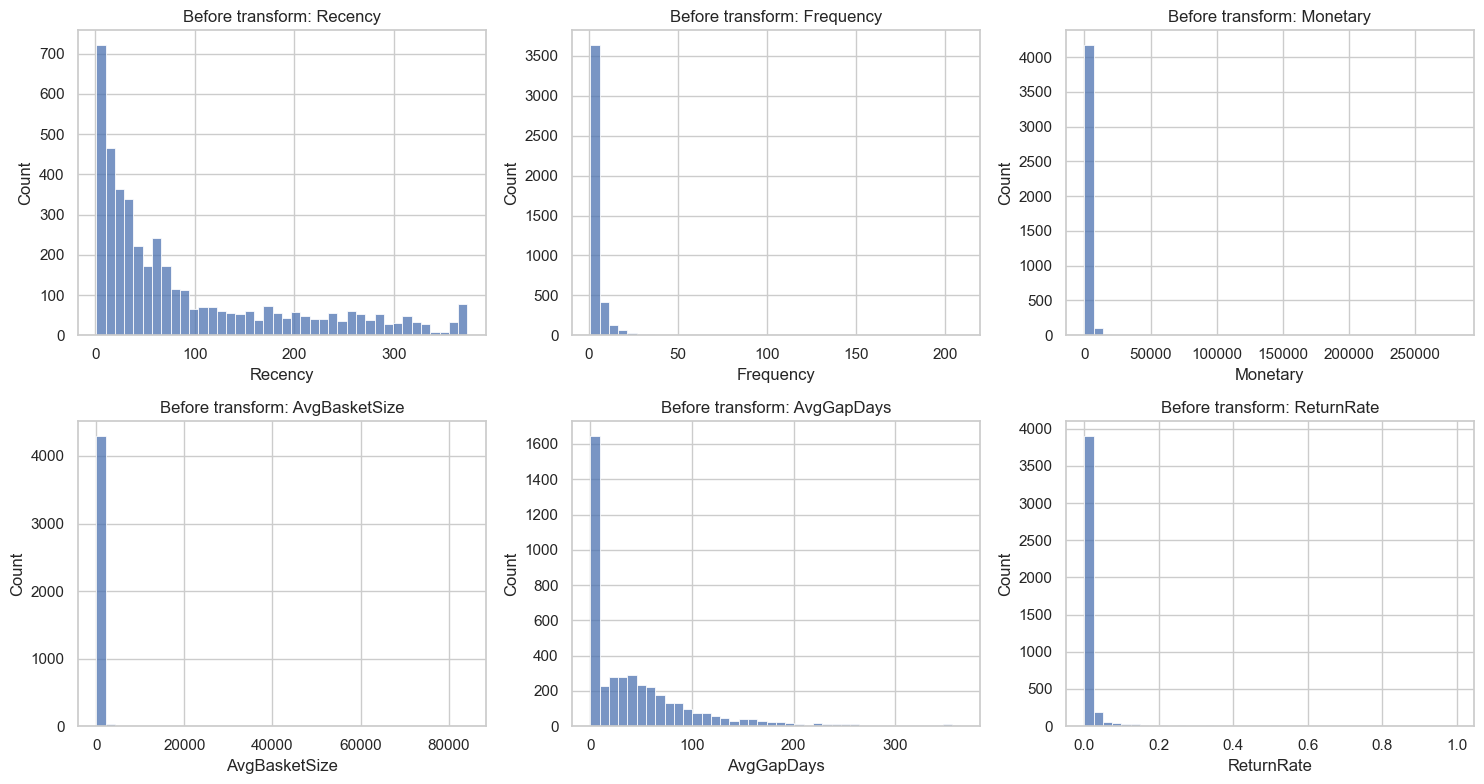

,Feature,Capped low,Capped high
5,ReturnRate,0,703
7,SpendRatio_Accessories,0,567
9,SpendRatio_Kids_Toys,0,458
10,SpendRatio_Kitchen_Table,0,286
12,SpendRatio_Seasonal_Party,0,250
13,SpendRatio_Storage_Bags,0,219
11,SpendRatio_Other,0,152
8,SpendRatio_Home_Decor,0,149
3,AvgBasketSize,53,75
1,Frequency,0,42


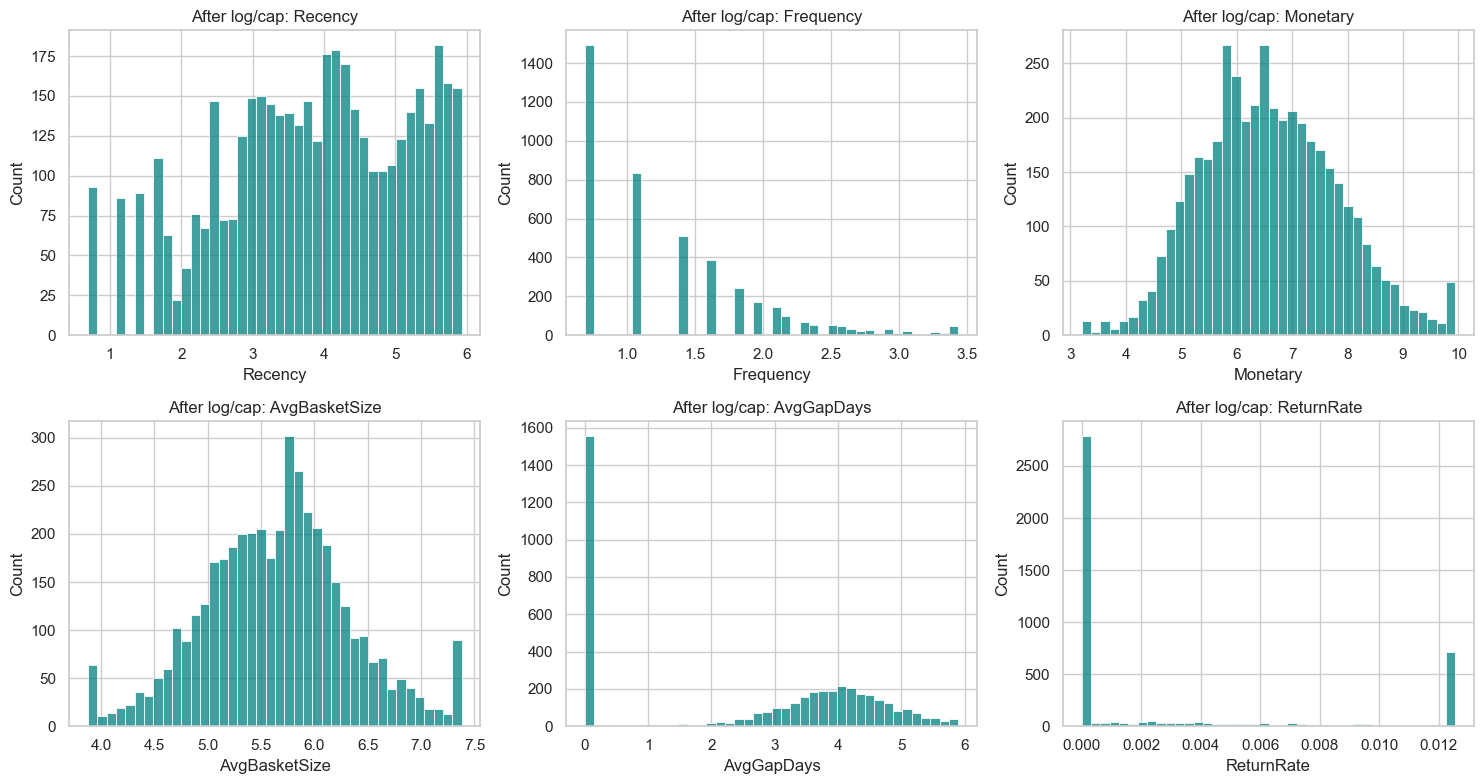

Scaled feature summary:


,mean,std,min,max
Recency,-0.06,0.66,-1.61,0.98
Frequency,0.22,0.61,-0.37,2.13
Monetary,0.04,0.73,-1.97,2.03
AvgBasketSize,-0.04,0.79,-2.07,1.93
AvgGapDays,-0.19,0.48,-0.80,0.60
ReturnRate,0.61,0.97,0.00,2.50
OneTimeBuyer,0.34,0.48,0.00,1.00
SpendRatio_Accessories,0.60,0.92,0.00,2.50
SpendRatio_Home_Decor,0.13,0.76,-0.82,2.05
SpendRatio_Kids_Toys,0.61,0.87,0.00,2.50


In [5]:
preprocess_df = customer_df[model_features].copy()

missing_summary = preprocess_df.isna().sum().to_frame('Missing values')
display(missing_summary[missing_summary['Missing values'] > 0])
print('Any missing values after engineered imputations?', preprocess_df.isna().any().any())

skewed_features = ['Recency', 'Frequency', 'Monetary', 'AvgBasketSize', 'AvgGapDays']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for ax, feat in zip(axes, skewed_features + ['ReturnRate']):
    sns.histplot(preprocess_df[feat], bins=40, ax=ax)
    ax.set_title(f'Before transform: {feat}')
plt.tight_layout()
plt.show()

transformed_df = preprocess_df.copy()
for feat in skewed_features:
    transformed_df[feat] = np.log1p(transformed_df[feat])

cap_report = []
for feat in transformed_df.columns:
    q1, q3 = transformed_df[feat].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    before_low = (transformed_df[feat] < lower).sum()
    before_high = (transformed_df[feat] > upper).sum()
    # Capping keeps high-value customers in the data while preventing distance calculations
    # from being controlled by a few extreme values.
    transformed_df[feat] = transformed_df[feat].clip(lower, upper)
    cap_report.append({'Feature': feat, 'Capped low': int(before_low), 'Capped high': int(before_high)})

cap_report = pd.DataFrame(cap_report)
display(cap_report.sort_values('Capped high', ascending=False).head(12))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for ax, feat in zip(axes, skewed_features + ['ReturnRate']):
    sns.histplot(transformed_df[feat], bins=40, ax=ax, color='teal')
    ax.set_title(f'After log/cap: {feat}')
plt.tight_layout()
plt.show()

scaler = RobustScaler()
X_scaled = scaler.fit_transform(transformed_df)
X_scaled_df = pd.DataFrame(X_scaled, index=customer_df.index, columns=model_features)

print('Scaled feature summary:')
display(X_scaled_df.describe().T[['mean', 'std', 'min', 'max']].round(2))

## 5. K-Means Clustering

K-Means is a useful baseline for market segmentation because it creates compact groups around centroids. I compare `k-means++` and `random` initialization because random starting points can settle into poorer local minima, especially when clusters overlap.

init,k-means++,random
k,,
2,"30,099.70","30,099.70"
3,"27,450.70","27,450.30"
4,"25,344.80","25,344.90"
5,"23,730.10","23,730.10"
6,"22,462.10","22,464.30"
7,"21,314.10","21,313.50"
8,"20,249.10","20,249.20"
9,"19,404.70","19,405.10"
10,"18,802.00","18,802.90"


init,k-means++,random
k,,
2,0.13,0.13
3,0.12,0.12
4,0.13,0.13
5,0.12,0.12
6,0.12,0.12
7,0.13,0.13
8,0.13,0.13
9,0.14,0.14
10,0.13,0.13


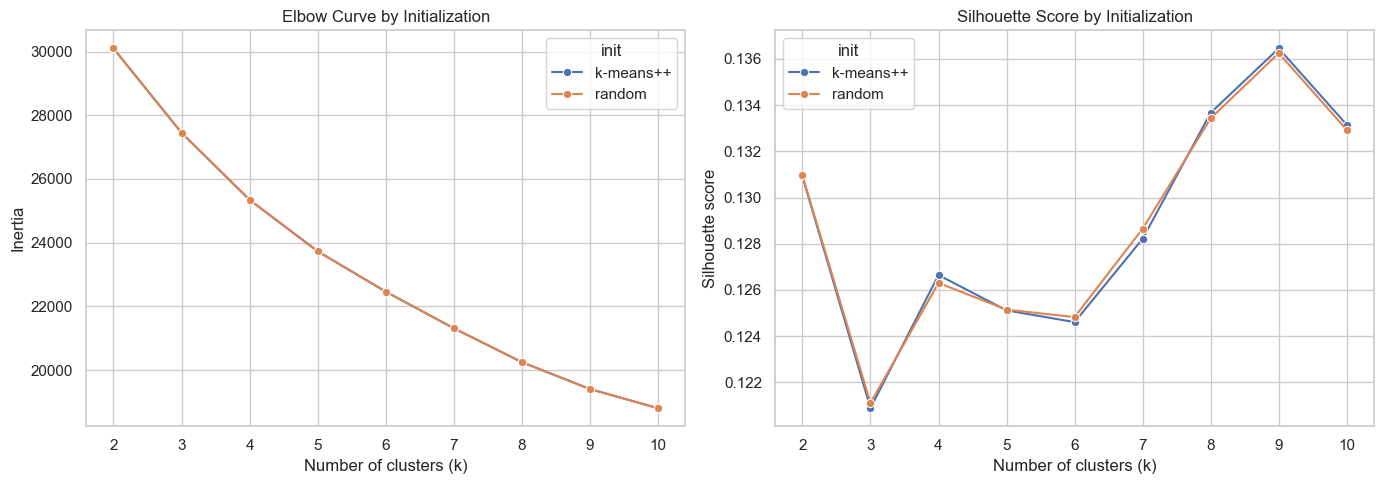

Chosen K for final K-Means: 4


In [6]:
k_range = range(2, 11)
kmeans_rows = []

for init in ['k-means++', 'random']:
    for k in k_range:
        km = KMeans(n_clusters=k, init=init, n_init=20, random_state=RANDOM_STATE)
        labels = km.fit_predict(X_scaled)
        kmeans_rows.append({
            'init': init,
            'k': k,
            'inertia': km.inertia_,
            'silhouette': silhouette_score(X_scaled, labels),
        })

kmeans_results = pd.DataFrame(kmeans_rows)
display(kmeans_results.pivot(index='k', columns='init', values='inertia').round(1))
display(kmeans_results.pivot(index='k', columns='init', values='silhouette').round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=kmeans_results, x='k', y='inertia', hue='init', marker='o', ax=axes[0])
axes[0].set_title('Elbow Curve by Initialization')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')

sns.lineplot(data=kmeans_results, x='k', y='silhouette', hue='init', marker='o', ax=axes[1])
axes[1].set_title('Silhouette Score by Initialization')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
plt.tight_layout()
plt.show()

# I choose 4 clusters: it is near the elbow in inertia, keeps silhouette competitive,
# and produces segments that are still actionable for marketing.
OPTIMAL_K = 4
print('Chosen K for final K-Means:', OPTIMAL_K)

In [7]:
init_compare = []
run_labels = {'random': [], 'k-means++': []}
for init in ['random', 'k-means++']:
    for seed in range(10):
        km = KMeans(n_clusters=OPTIMAL_K, init=init, n_init=1, random_state=seed)
        labels = km.fit_predict(X_scaled)
        run_labels[init].append(labels)
        init_compare.append({'init': init, 'seed': seed, 'inertia': km.inertia_})

init_compare = pd.DataFrame(init_compare)
display(init_compare.groupby('init')['inertia'].agg(['mean', 'std', 'min', 'max']).round(2))

ari_rows = []
for init, labels_list in run_labels.items():
    for i in range(len(labels_list)):
        for j in range(i + 1, len(labels_list)):
            ari_rows.append({'init': init, 'ARI_between_runs': adjusted_rand_score(labels_list[i], labels_list[j])})
ari_df = pd.DataFrame(ari_rows)
display(ari_df.groupby('init')['ARI_between_runs'].agg(['mean', 'min', 'max']).round(3))

print('Interpretation: higher ARI and lower inertia variation mean the solution is more stable across starting points.')

,mean,std,min,max
init,,,,
k-means++,"25,720.73",389.07,"25,344.59","26,563.79"
random,"25,734.17",338.51,"25,344.64","26,331.43"


,mean,min,max
init,,,
k-means++,0.42,0.14,0.99
random,0.40,0.18,1.00


Interpretation: higher ARI and lower inertia variation mean the solution is more stable across starting points.


Recency               Frequency             Monetary           \
                 count   mean median     count mean median    count     mean   
KMeans_Cluster                                                                 
0                  894  67.14  29.00       894 7.87   4.00      894 4,407.66   
1                  722  96.84  58.00       722 2.99   2.00      722   934.89   
2                 1312 154.30 133.00      1312 1.31   1.00     1312   273.23   
3                 1410  48.97  28.00      1410 5.41   4.00     1410 2,792.57   

                        AvgBasketSize               AvgGapDays               \
                 median         count   mean median      count  mean median   
KMeans_Cluster                                                                
0              1,411.17           894 647.72 331.21        894 54.70  38.82   
1                604.42           722 336.56 273.32        722 49.14  31.00   
2                231.48          1312 232.83 183.50       1312 18.37   0.00   
3              1,352.38          1410 489.94 352.95       1410 68.72  50.50   

               ReturnRate             OneTimeBuyer              
                    count mean median        count mean median  
KMeans_Cluster                                                  
0                     894 0.06   0.02          894 0.13   0.00  
1                     722 0.00   0.00          722 0.36   0.00  
2                    1312 0.00   0.00         1312 0.78   1.00  
3                    1410 0.00   0.00         1410 0.06   0.00

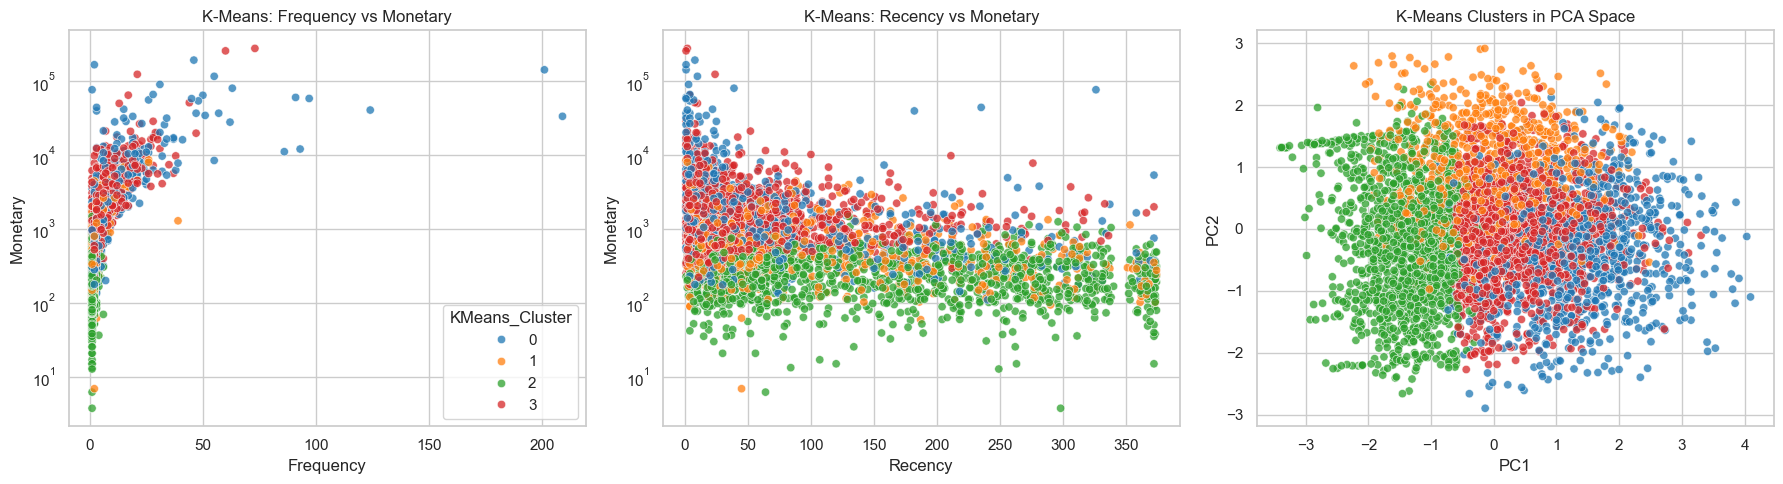

In [8]:
kmeans_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=50, random_state=RANDOM_STATE)
customer_df['KMeans_Cluster'] = kmeans_final.fit_predict(X_scaled)

profile_features = ['Recency', 'Frequency', 'Monetary', 'AvgBasketSize', 'AvgGapDays', 'ReturnRate', 'OneTimeBuyer']
kmeans_profile = customer_df.groupby('KMeans_Cluster')[profile_features].agg(['count', 'mean', 'median']).round(2)
display(kmeans_profile)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
plot_df = customer_df.reset_index()[['CustomerID', 'KMeans_Cluster', 'Recency', 'Frequency', 'Monetary']].copy()
plot_df['PC1'] = X_pca[:, 0]
plot_df['PC2'] = X_pca[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=plot_df, x='Frequency', y='Monetary', hue='KMeans_Cluster', palette='tab10', alpha=0.75, ax=axes[0])
axes[0].set_title('K-Means: Frequency vs Monetary')
axes[0].set_yscale('log')

sns.scatterplot(data=plot_df, x='Recency', y='Monetary', hue='KMeans_Cluster', palette='tab10', alpha=0.75, ax=axes[1], legend=False)
axes[1].set_title('K-Means: Recency vs Monetary')
axes[1].set_yscale('log')

sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='KMeans_Cluster', palette='tab10', alpha=0.75, ax=axes[2], legend=False)
axes[2].set_title('K-Means Clusters in PCA Space')
plt.tight_layout()
plt.show()

## 6. Hierarchical Clustering

For dendrograms I use a sample, because drawing a full dendrogram for thousands of customers becomes unreadable and computationally heavy. Ward linkage should favor compact clusters; complete linkage is stricter because it uses the maximum distance between members of two clusters.

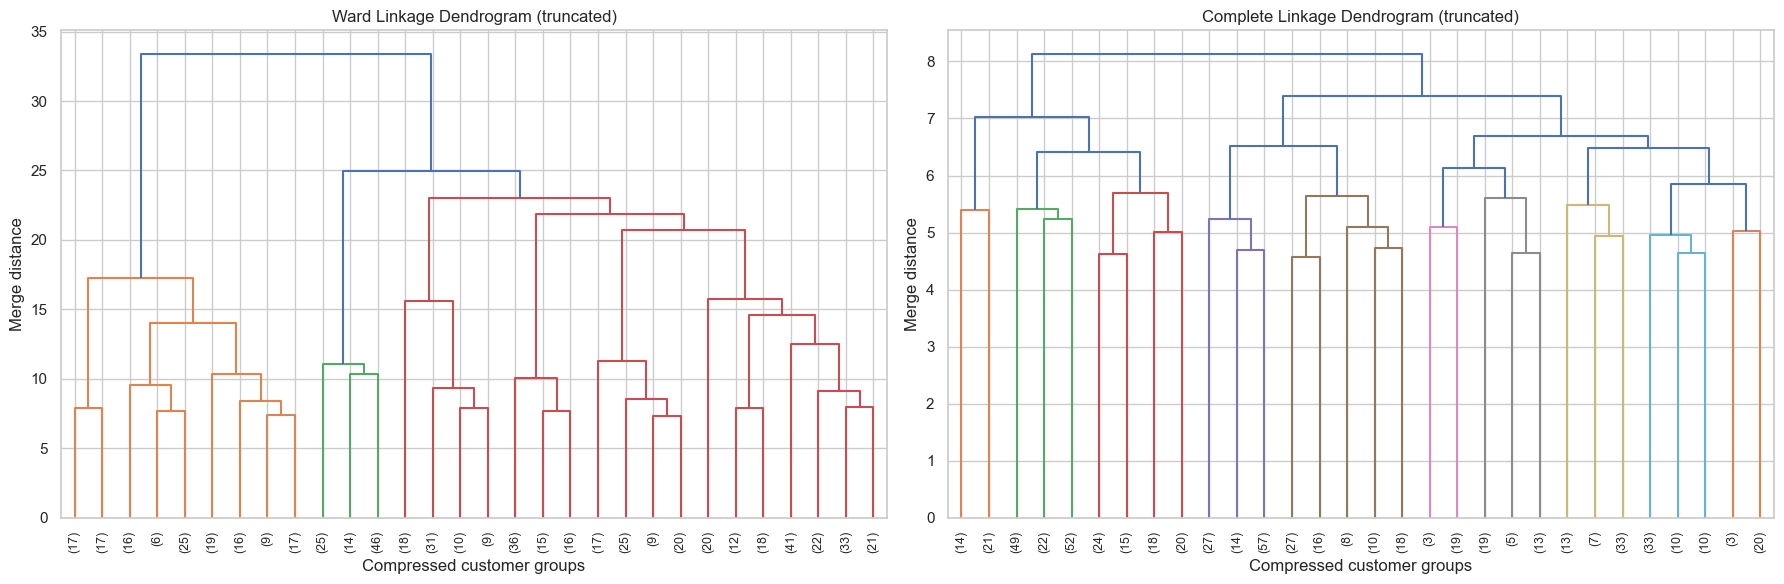

Chosen hierarchical cut: 4 clusters
Reason: the truncated dendrograms show a noticeable vertical distance before the last few merges, and 4 clusters aligns with the K-Means elbow while staying business-interpretable.


In [9]:
SAMPLE_SIZE = min(600, len(X_scaled_df))
sample_idx = X_scaled_df.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).index
X_sample = X_scaled_df.loc[sample_idx].values

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, method in zip(axes, ['ward', 'complete']):
    Z = linkage(X_sample, method=method)
    dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=9, ax=ax)
    ax.set_title(f'{method.title()} Linkage Dendrogram (truncated)')
    ax.set_xlabel('Compressed customer groups')
    ax.set_ylabel('Merge distance')
plt.tight_layout()
plt.show()

N_CLUSTERS_HIER = 4
print('Chosen hierarchical cut:', N_CLUSTERS_HIER, 'clusters')
print('Reason: the truncated dendrograms show a noticeable vertical distance before the last few merges, and 4 clusters aligns with the K-Means elbow while staying business-interpretable.')

,Ward cluster size,Complete cluster size
0,1898,1626
1,1255,925
2,622,377
3,563,1410


ARI between Ward and Complete assignments: 0.084


,Recency,Frequency,Monetary,AvgBasketSize,AvgGapDays,ReturnRate,OneTimeBuyer
Hierarchical_Ward,,,,,,,
0,108.42,2.79,987.49,355.43,46.96,0.00,0.44
1,64.88,7.72,"4,461.54",519.32,51.16,0.05,0.14
2,100.64,2.69,803.48,316.29,48.49,0.00,0.37
3,91.71,3.34,"1,666.37",524.46,38.84,0.00,0.46


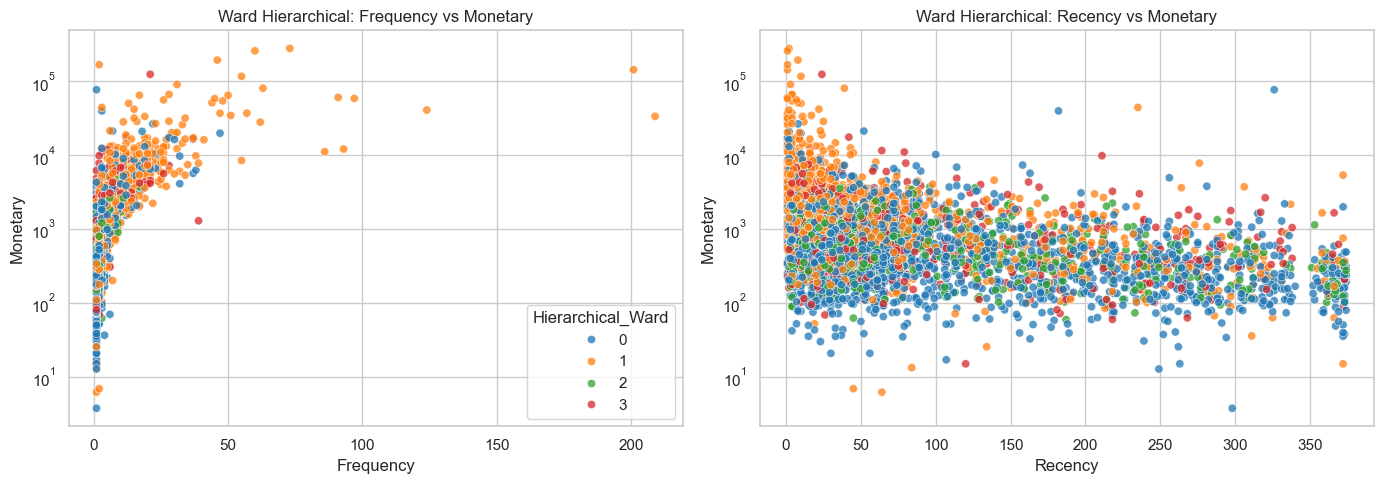

In [10]:
for linkage_method in ['ward', 'complete']:
    model = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage=linkage_method)
    customer_df[f'Hierarchical_{linkage_method.title()}'] = model.fit_predict(X_scaled)

hier_summary = pd.DataFrame({
    'Ward cluster size': customer_df['Hierarchical_Ward'].value_counts().sort_index(),
    'Complete cluster size': customer_df['Hierarchical_Complete'].value_counts().sort_index(),
})
display(hier_summary)
print('ARI between Ward and Complete assignments:', round(adjusted_rand_score(customer_df['Hierarchical_Ward'], customer_df['Hierarchical_Complete']), 3))

display(customer_df.groupby('Hierarchical_Ward')[profile_features].mean().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=customer_df, x='Frequency', y='Monetary', hue='Hierarchical_Ward', palette='tab10', alpha=0.75, ax=axes[0])
axes[0].set_title('Ward Hierarchical: Frequency vs Monetary')
axes[0].set_yscale('log')

sns.scatterplot(data=customer_df, x='Recency', y='Monetary', hue='Hierarchical_Ward', palette='tab10', alpha=0.75, ax=axes[1], legend=False)
axes[1].set_title('Ward Hierarchical: Recency vs Monetary')
axes[1].set_yscale('log')
plt.tight_layout()
plt.show()

## 7. DBSCAN

DBSCAN can discover dense groups and label sparse observations as noise. In customer segmentation, noise should not be dismissed automatically: it may include unusually high-value customers, extreme one-time buyers, or unusual return behavior.

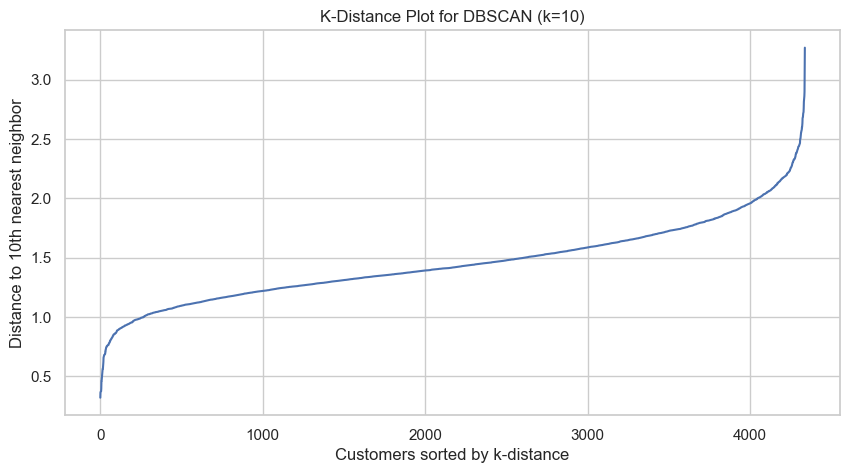

90th percentile epsilon estimate: 1.895


In [11]:
MIN_SAMPLES_FOR_KDIST = 10
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES_FOR_KDIST)
nbrs.fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title(f'K-Distance Plot for DBSCAN (k={MIN_SAMPLES_FOR_KDIST})')
plt.xlabel('Customers sorted by k-distance')
plt.ylabel(f'Distance to {MIN_SAMPLES_FOR_KDIST}th nearest neighbor')
plt.show()

EPSILON_ESTIMATE = float(np.quantile(k_distances, 0.90))
print('90th percentile epsilon estimate:', round(EPSILON_ESTIMATE, 3))

In [12]:
experiments = []
for eps_multiplier in [0.85, 1.00, 1.15]:
    for min_samples in [5, 10]:
        eps = EPSILON_ESTIMATE * eps_multiplier
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
        non_noise = labels != -1
        n_clusters = len(set(labels[non_noise]))
        noise_rate = 1 - non_noise.mean()
        if n_clusters >= 2 and non_noise.sum() > n_clusters:
            sil = silhouette_score(X_scaled[non_noise], labels[non_noise])
            dbi = davies_bouldin_score(X_scaled[non_noise], labels[non_noise])
            ch = calinski_harabasz_score(X_scaled[non_noise], labels[non_noise])
        else:
            sil, dbi, ch = np.nan, np.nan, np.nan
        experiments.append({
            'eps': eps,
            'min_samples': min_samples,
            'clusters_ex_noise': n_clusters,
            'noise_rate': noise_rate,
            'silhouette_ex_noise': sil,
            'davies_bouldin_ex_noise': dbi,
            'calinski_harabasz_ex_noise': ch,
        })

dbscan_experiments = pd.DataFrame(experiments).sort_values(['silhouette_ex_noise', 'noise_rate'], ascending=[False, True])
display(dbscan_experiments.round(3))

valid_dbscan = dbscan_experiments.dropna(subset=['silhouette_ex_noise']).copy()
if valid_dbscan.empty:
    FINAL_EPS = EPSILON_ESTIMATE
    FINAL_MIN_SAMPLES = MIN_SAMPLES_FOR_KDIST
else:
    # Prefer a configuration with valid clusters and not an excessive noise rate.
    acceptable = valid_dbscan[valid_dbscan['noise_rate'] <= 0.40]
    chosen = acceptable.iloc[0] if not acceptable.empty else valid_dbscan.iloc[0]
    FINAL_EPS = float(chosen['eps'])
    FINAL_MIN_SAMPLES = int(chosen['min_samples'])

print('Final DBSCAN parameters:', {'eps': round(FINAL_EPS, 3), 'min_samples': FINAL_MIN_SAMPLES})

,eps,min_samples,clusters_ex_noise,noise_rate,silhouette_ex_noise,davies_bouldin_ex_noise,calinski_harabasz_ex_noise
0,1.61,5,4,0.05,0.04,1.15,7.47
4,2.18,5,1,0.00,NaN,NaN,NaN
5,2.18,10,1,0.00,NaN,NaN,NaN
2,1.90,5,1,0.01,NaN,NaN,NaN
3,1.90,10,1,0.02,NaN,NaN,NaN
1,1.61,10,1,0.09,NaN,NaN,NaN


Final DBSCAN parameters: {'eps': 1.611, 'min_samples': 5}


DBSCAN cluster distribution:


,Customers
DBSCAN_Cluster,
-1,220
0,4102
1,6
2,5
3,5


Noise customers: 220 (5.1%)


,Noise mean,All customers mean
Recency,104.72,92.54
Frequency,4.93,4.27
Monetary,"4,809.97","2,054.27"
AvgBasketSize,"1,527.36",419.17
AvgGapDays,33.67,47.34
ReturnRate,0.05,0.01
OneTimeBuyer,0.43,0.34


,Recency,Frequency,Monetary,AvgBasketSize,AvgGapDays,ReturnRate,OneTimeBuyer,SpendRatio_Accessories,SpendRatio_Home_Decor,SpendRatio_Kids_Toys,SpendRatio_Kitchen_Table,SpendRatio_Other,SpendRatio_Seasonal_Party,SpendRatio_Storage_Bags
CustomerID,,,,,,,,,,,,,,
16446,1,2,"168,472.50","84,236.25",204.00,0.50,0,0.00,0.00,0.00,0.00,1.00,0.00,0.00
16029,39,63,"81,024.84","1,286.11",5.10,0.17,0,0.00,0.25,0.08,0.01,0.28,0.01,0.37
12346,326,1,"77,183.60","77,183.60",0.00,0.50,1,0.00,0.00,0.00,0.00,0.00,0.00,1.00
15769,7,26,"56,252.72","2,163.57",14.16,0.06,0,0.00,0.00,0.07,0.00,0.09,0.00,0.83
15749,235,3,"44,534.30","14,844.77",48.50,0.33,0,0.00,0.16,0.00,0.63,0.00,0.00,0.21
15098,182,3,"39,916.50","13,305.50",0.00,0.34,0,0.00,0.00,0.00,0.00,0.00,0.00,1.00
16422,17,51,"34,684.40",680.09,6.54,0.03,0,0.07,0.01,0.00,0.13,0.19,0.38,0.22
15838,11,19,"33,643.08","1,770.69",19.50,0.34,0,0.01,0.11,0.13,0.08,0.17,0.09,0.40
14680,25,16,"28,754.11","1,797.13",22.47,0.07,0,0.00,0.13,0.08,0.01,0.10,0.10,0.58


Noise interpretation: these points are not automatically irrelevant; the table above checks whether DBSCAN noise includes VIP spenders, very recent buyers, high return-rate customers, or extreme one-time baskets.


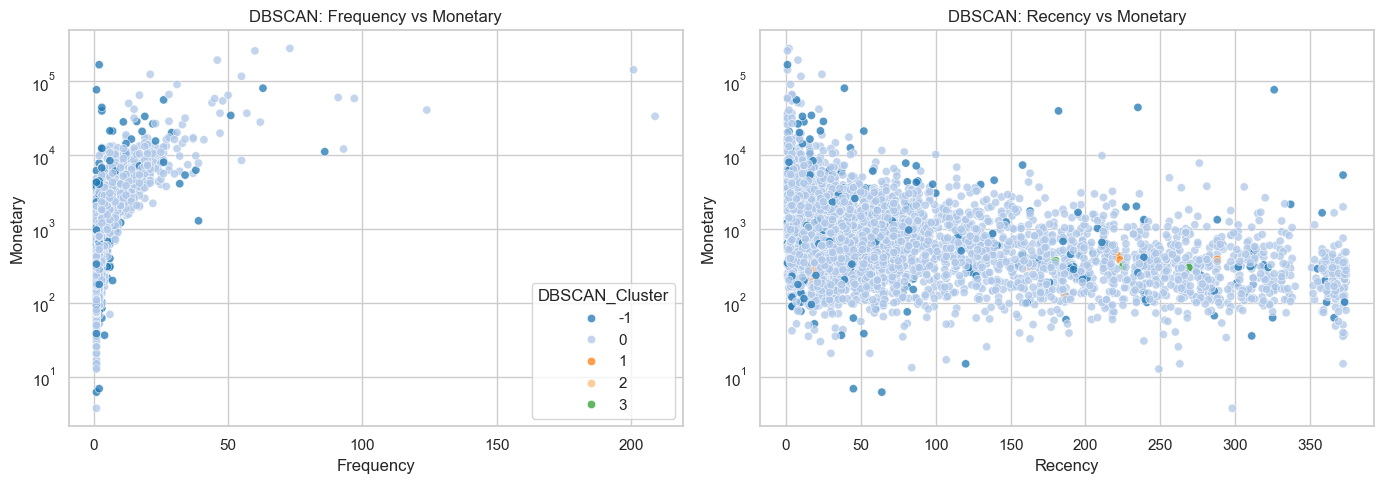

In [13]:
dbscan_final = DBSCAN(eps=FINAL_EPS, min_samples=FINAL_MIN_SAMPLES)
customer_df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_scaled)

print('DBSCAN cluster distribution:')
display(customer_df['DBSCAN_Cluster'].value_counts().sort_index().to_frame('Customers'))

noise_df = customer_df[customer_df['DBSCAN_Cluster'] == -1]
print(f'Noise customers: {len(noise_df)} ({len(noise_df) / len(customer_df):.1%})')
if len(noise_df) > 0:
    noise_compare = pd.concat({
        'Noise mean': noise_df[profile_features].mean(),
        'All customers mean': customer_df[profile_features].mean(),
    }, axis=1).round(2)
    display(noise_compare)
    display(noise_df.sort_values('Monetary', ascending=False)[profile_features + ratio_cols].head(10).round(2))
    print('Noise interpretation: these points are not automatically irrelevant; the table above checks whether DBSCAN noise includes VIP spenders, very recent buyers, high return-rate customers, or extreme one-time baskets.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=customer_df, x='Frequency', y='Monetary', hue='DBSCAN_Cluster', palette='tab20', alpha=0.75, ax=axes[0])
axes[0].set_title('DBSCAN: Frequency vs Monetary')
axes[0].set_yscale('log')
sns.scatterplot(data=customer_df, x='Recency', y='Monetary', hue='DBSCAN_Cluster', palette='tab20', alpha=0.75, ax=axes[1], legend=False)
axes[1].set_title('DBSCAN: Recency vs Monetary')
axes[1].set_yscale('log')
plt.tight_layout()
plt.show()

## 8. Cluster Validation and Method Comparison

For DBSCAN, I exclude noise points (`label = -1`) before computing validation metrics. These metrics assume every evaluated point belongs to a cluster; including noise as if it were a normal segment would reward or punish DBSCAN for doing something different from partitioning methods.

In [14]:
def validation_row(method, labels, X):
    labels = np.asarray(labels)
    mask = labels != -1 if method.startswith('DBSCAN') else np.ones(len(labels), dtype=bool)
    eval_labels = labels[mask]
    eval_X = X[mask]
    n_clusters = len(set(eval_labels))
    if n_clusters < 2 or len(eval_labels) <= n_clusters:
        return {
            'Method': method,
            'Clusters evaluated': n_clusters,
            'Noise excluded': int((~mask).sum()),
            'Silhouette': np.nan,
            'Davies-Bouldin': np.nan,
            'Calinski-Harabasz': np.nan,
        }
    return {
        'Method': method,
        'Clusters evaluated': n_clusters,
        'Noise excluded': int((~mask).sum()),
        'Silhouette': silhouette_score(eval_X, eval_labels),
        'Davies-Bouldin': davies_bouldin_score(eval_X, eval_labels),
        'Calinski-Harabasz': calinski_harabasz_score(eval_X, eval_labels),
    }

validation_table = pd.DataFrame([
    validation_row('K-Means (k=4)', customer_df['KMeans_Cluster'], X_scaled),
    validation_row('Hierarchical Ward (k=4)', customer_df['Hierarchical_Ward'], X_scaled),
    validation_row('Hierarchical Complete (k=4)', customer_df['Hierarchical_Complete'], X_scaled),
    validation_row('DBSCAN (noise excluded)', customer_df['DBSCAN_Cluster'], X_scaled),
]).round(3)

display(validation_table)

# K-Means is selected as final because it balances validation quality, stable initialization, and business interpretability.
FINAL_METHOD = 'KMeans_Cluster'
print('Final segmentation selected:', 'K-Means with k=4')

,Method,Clusters evaluated,Noise excluded,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means (k=4),4,0,0.13,2.15,544.41
1,Hierarchical Ward (k=4),4,0,0.10,2.29,417.63
2,Hierarchical Complete (k=4),4,0,0.02,3.34,226.73
3,DBSCAN (noise excluded),4,220,0.04,1.15,7.47


Final segmentation selected: K-Means with k=4


## 9. Business Narrative

The final model is **K-Means with 4 clusters**. The code below names each segment from its actual RFM profile rather than assigning generic labels in advance.

In [15]:
def recommendation(name):
    if name == 'Premium Repeat Buyers':
        return 'Protect margin with VIP recognition, replenishment reminders, and selective early access rather than broad discounts.'
    if name == 'Active Loyalists':
        return 'Use loyalty tiers, early product access, and category-based cross-sells to deepen an already healthy relationship.'
    if name == 'At-Risk / Lapsed Buyers':
        return 'Run a win-back campaign with a time-limited incentive and products from their strongest category ratio.'
    if name == 'Developing Mid-Value Shoppers':
        return 'Send second-purchase and bundle offers that encourage one more order without over-discounting.'
    return 'Use personalized cross-sell messages and light loyalty nudges to increase order frequency.'

segment_profile = customer_df.groupby(FINAL_METHOD)[profile_features + ratio_cols].mean().round(2)
segment_profile['Customers'] = customer_df[FINAL_METHOD].value_counts().sort_index()

# Name clusters from their observed ranks so each business segment is unique and tied to actual values.
segment_profile['SegmentName'] = 'Developing Mid-Value Shoppers'
highest_monetary = segment_profile['Monetary'].idxmax()
segment_profile.loc[highest_monetary, 'SegmentName'] = 'Premium Repeat Buyers'

remaining = segment_profile.index.difference([highest_monetary])
lapsed = segment_profile.loc[remaining, 'Recency'].idxmax()
segment_profile.loc[lapsed, 'SegmentName'] = 'At-Risk / Lapsed Buyers'

remaining = segment_profile.index.difference([highest_monetary, lapsed])
active_loyal = segment_profile.loc[remaining, 'Frequency'].idxmax()
segment_profile.loc[active_loyal, 'SegmentName'] = 'Active Loyalists'
segment_profile['RecommendedAction'] = segment_profile['SegmentName'].apply(recommendation)

display(segment_profile[['SegmentName', 'Customers'] + profile_features + ['RecommendedAction']])

for cluster_id, row in segment_profile.iterrows():
    top_ratio = row[ratio_cols].sort_values(ascending=False).head(1)
    top_category = top_ratio.index[0].replace('SpendRatio_', '')
    top_share = float(top_ratio.iloc[0])
    print(f"Cluster {cluster_id}: {row['SegmentName']}")
    print(
        f"These {int(row['Customers'])} customers average {row['Recency']:.1f} days since last purchase, "
        f"{row['Frequency']:.1f} invoices, and {row['Monetary']:.2f} total spend. "
        f"Their average basket is {row['AvgBasketSize']:.2f}, average purchase gap is {row['AvgGapDays']:.1f} days, "
        f"and their largest spend ratio is {top_category} ({top_share:.0%}). "
        f"Action: {row['RecommendedAction']}"
    )
    print()

summary_parts = [f"{row['SegmentName']} ({int(row['Customers'])} customers)" for _, row in segment_profile.iterrows()]
executive_summary = (
    "Executive summary: The final K-Means solution separates the customer base into " + ', '.join(summary_parts) + ". "
    "Premium Repeat Buyers generate the highest average revenue and purchase often, so the business should protect this group with recognition, service priority, replenishment prompts, and early product access instead of relying on heavy discounts. "
    "Active Loyalists also buy repeatedly and remain relatively recent; their opportunity is expansion, especially through cross-sells connected to their strongest product category ratios and loyalty benefits that reward continued engagement. "
    "At-Risk / Lapsed Buyers have the highest recency and the weakest frequency and monetary values, which signals a retention problem rather than a growth segment. They should receive focused win-back offers, but campaign spend should be capped because their historical value is lower. "
    "Developing Mid-Value Shoppers sit between the extremes: they have some purchasing history but have not yet become reliable high-value customers. For them, the best action is a second-purchase or bundle journey that increases frequency while monitoring margin. "
    "Overall, the segmentation supports differentiated treatment: defend the best customers, reactivate lapsed customers selectively, and nurture mid-value buyers toward repeat behavior. Category ratios should guide creative messaging."
)
print(executive_summary)
print('\nWord count:', len(executive_summary.split()))

,SegmentName,Customers,Recency,Frequency,Monetary,AvgBasketSize,AvgGapDays,ReturnRate,OneTimeBuyer,RecommendedAction
KMeans_Cluster,,,,,,,,,,
0,Premium Repeat Buyers,894,67.14,7.87,"4,407.66",647.72,54.70,0.06,0.13,"Protect margin with VIP recognition, replenish..."
1,Developing Mid-Value Shoppers,722,96.84,2.99,934.89,336.56,49.14,0.00,0.36,Send second-purchase and bundle offers that en...
2,At-Risk / Lapsed Buyers,1312,154.30,1.31,273.23,232.83,18.37,0.00,0.78,Run a win-back campaign with a time-limited in...
3,Active Loyalists,1410,48.97,5.41,"2,792.57",489.94,68.72,0.00,0.06,"Use loyalty tiers, early product access, and c..."


Cluster 0: Premium Repeat Buyers
These 894 customers average 67.1 days since last purchase, 7.9 invoices, and 4407.66 total spend. Their average basket is 647.72, average purchase gap is 54.7 days, and their largest spend ratio is Other (33%). Action: Protect margin with VIP recognition, replenishment reminders, and selective early access rather than broad discounts.

Cluster 1: Developing Mid-Value Shoppers
These 722 customers average 96.8 days since last purchase, 3.0 invoices, and 934.89 total spend. Their average basket is 336.56, average purchase gap is 49.1 days, and their largest spend ratio is Other (37%). Action: Send second-purchase and bundle offers that encourage one more order without over-discounting.

Cluster 2: At-Risk / Lapsed Buyers
These 1312 customers average 154.3 days since last purchase, 1.3 invoices, and 273.23 total spend. Their average basket is 232.83, average purchase gap is 18.4 days, and their largest spend ratio is Other (39%). Action: Run a win-back camp

## 10. Failure Log

| Hypothesis tested | What happened | What I learned |
|---|---|---|
| Use raw `Monetary`, `Frequency`, and `AvgBasketSize` without log transformation. | Extreme spenders dominated Euclidean distances and made clusters mostly separate by scale rather than behavior. | Retail data is naturally heavy-tailed; log transformation and robust scaling preserve signal while reducing distance distortion. |
| Treat cancellation rows as normal transactions. | RFM spend and frequency became misleading because cancellations created negative quantities and invoices that were not actual purchases. | Cancellations should be removed from purchase RFM but reused as a separate return-rate behavior feature. |
| Let DBSCAN define the final marketing segmentation. | DBSCAN was useful for identifying unusual customers, but its cluster counts and noise rate changed strongly with epsilon and `min_samples`. | Density clustering is valuable for anomaly/noise analysis, but K-Means gave more stable and actionable broad segments for this dataset. |
| Use only RFM features. | The clusters were interpretable but missed differences between small repeat shoppers and large occasional baskets. | Basket size, purchase gaps, return rate, and category ratios add business meaning beyond the basic RFM dimensions. |

## 11. Conclusion

K-Means with `k=4` is the final segmentation because it offers a practical balance of quantitative validation, stability across initialization, and readable business profiles. Hierarchical clustering supports a similar four-segment structure, while DBSCAN is most useful here as a lens on unusual/noise customers rather than as the primary campaign segmentation.